<a href="https://colab.research.google.com/github/RamiroIsaJ/Aprendizaje_maquina_ML/blob/main/Foro_2_Algoritmos_Boosting_RIJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** Taller 2 de Métodos de Aprendizaje de Máquina **
* Por: Ramiro Isa Jara
* Fecha: 12 de julio de 2026

In [ ]:
# 1. Carga del dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import copy

os.chdir('..')

data = pd.read_csv('/content/drive/MyDrive/Aprendizaje_maquina_UTPL/Trabajos/winequality-whitelabel.csv', delimiter=',', encoding='unicode_escape')
print('Dataset loaded succesfully')

Dataset loaded succesfully


In [ ]:
# 2 (a). Analisis de las columnas del dataset
data.info(verbose=True)
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4898 non-null   int64  
 1   fixed acidity         4898 non-null   float64
 2   volatile acidity      4898 non-null   float64
 3   citric acid           4898 non-null   float64
 4   residual sugar        4898 non-null   float64
 5   chlorides             4898 non-null   float64
 6   free sulfur dioxide   4898 non-null   float64
 7   total sulfur dioxide  4898 non-null   float64
 8   density               4898 non-null   float64
 9   pH                    4898 non-null   float64
 10  sulphates             4898 non-null   float64
 11  alcohol               4898 non-null   float64
 12  quality_label         4898 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 497.6+ KB


,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,2448.500000,6.843069,0.274126,0.330196,6.376756,0.043510,35.101776,138.233156,0.994017,3.187104,0.487771,10.514267
std,1414.075139,0.800015,0.087203,0.103506,4.983099,0.011295,16.008071,41.959107,0.002910,0.147199,0.107641,1.230621
min,0.000000,4.800000,0.080000,0.090000,0.600000,0.015000,2.000000,19.500000,0.987110,2.805000,0.220000,8.000000
25%,1224.250000,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000
50%,2448.500000,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000
75%,3672.750000,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000
max,4897.000000,8.800000,0.485000,0.570000,22.200000,0.071000,80.500000,255.500000,1.002666,3.565000,0.760000,14.200000


In [ ]:
data=data.drop(['Unnamed: 0'], axis=1)

In [ ]:
# 2(b): revision de los datos
data.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_label
4252,6.7,0.11,0.26,14.8,0.053,44.0,95.0,0.99676,3.20,0.35,9.8,medium
1569,6.7,0.30,0.57,5.0,0.038,35.0,157.0,0.99450,3.21,0.46,9.9,low
2039,8.7,0.24,0.35,0.6,0.042,11.0,71.0,0.99260,3.08,0.38,10.6,low
2060,6.8,0.28,0.44,11.5,0.040,58.0,223.0,0.99690,3.22,0.56,9.5,low
1786,7.4,0.33,0.26,2.6,0.040,29.0,115.0,0.99130,3.07,0.52,11.8,medium
2910,6.1,0.37,0.20,7.6,0.031,49.0,170.0,0.99558,3.22,0.48,9.5,low
934,6.2,0.28,0.43,13.0,0.039,64.0,233.0,0.99745,3.08,0.38,8.9,low
2234,7.2,0.23,0.38,6.1,0.067,20.0,90.0,0.99496,3.17,0.76,9.7,low
4297,7.0,0.20,0.35,8.8,0.037,31.0,103.0,0.99388,3.13,0.49,11.0,medium
2769,7.3,0.32,0.35,1.4,0.050,8.0,163.0,0.99244,3.24,0.42,10.7,low


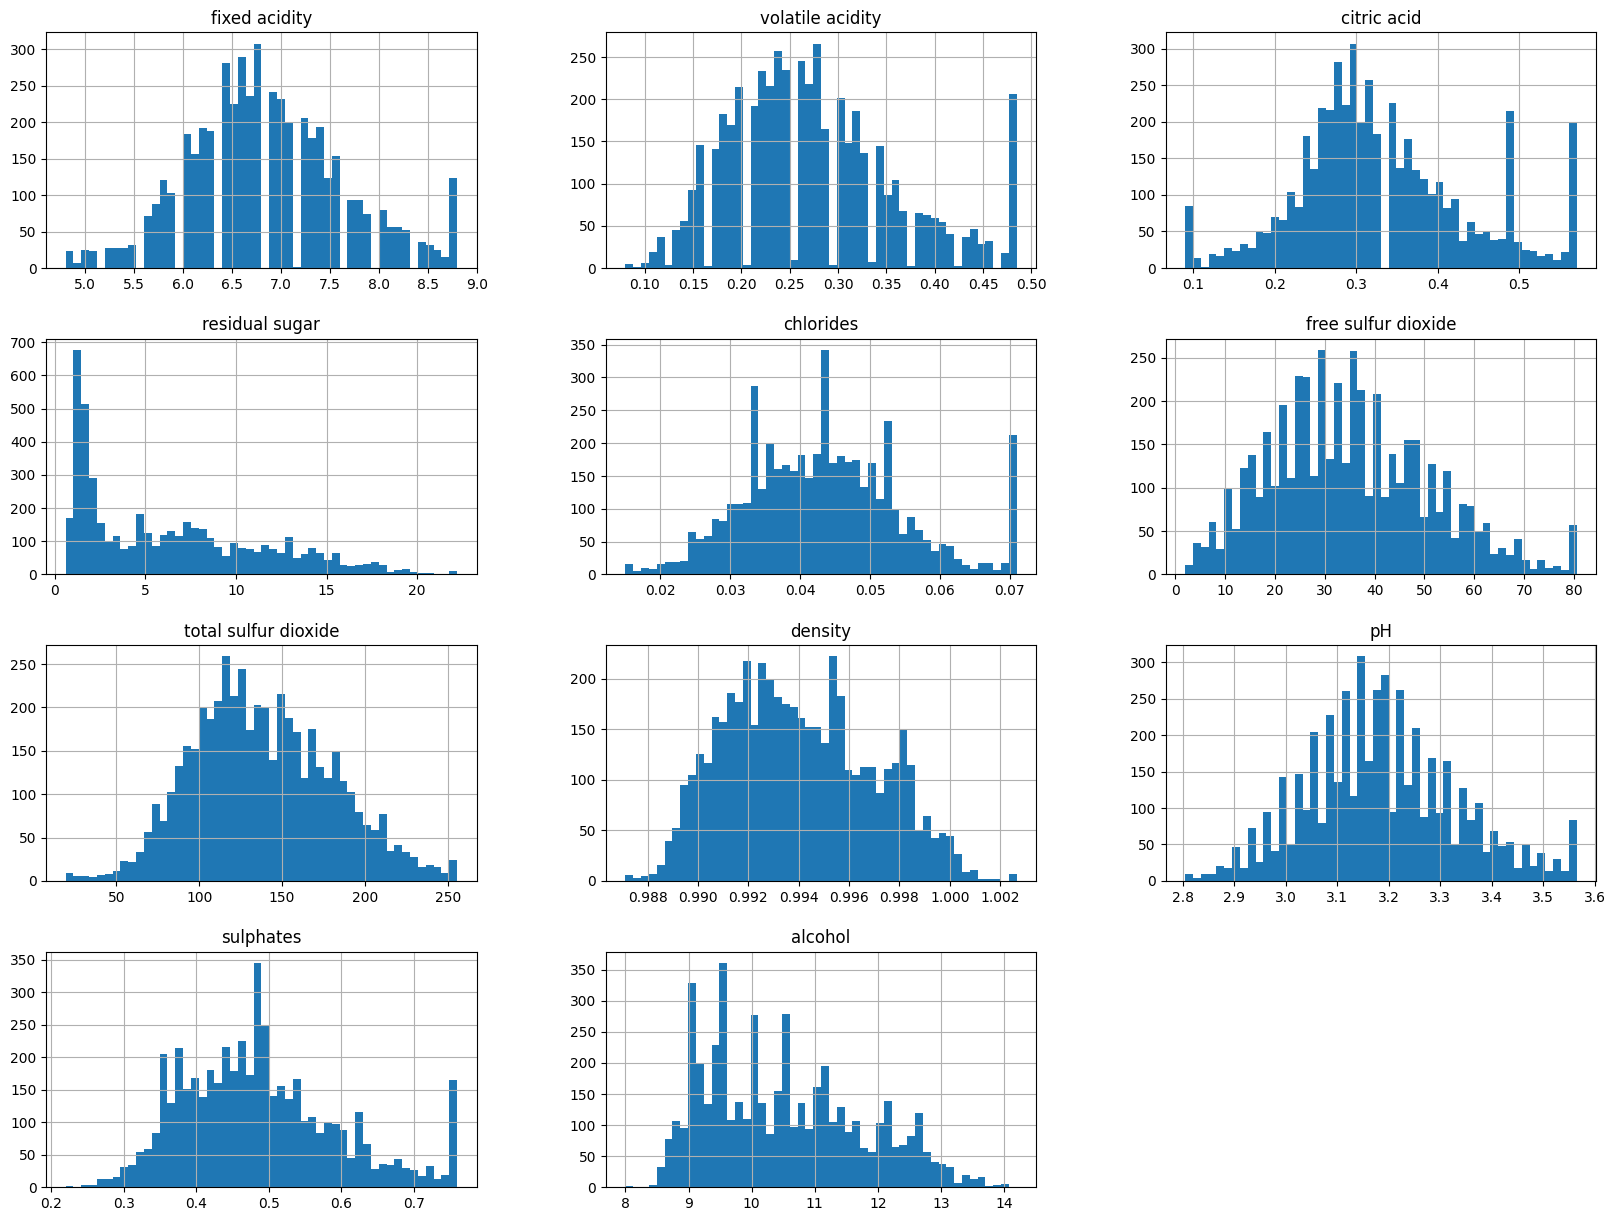

In [ ]:
# 2(c): graficas de los datos
data.hist(bins=50, figsize=(20,15))
plt.show()

**Tratamiento de los datos**

In [ ]:
# Seleccionar columnas numéricas
numeric_cols = data.select_dtypes(include=np.number).columns

# Aplicar capping con IQR
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Reemplazar outliers por límites
    data[col] = data[col].clip(lower, upper)

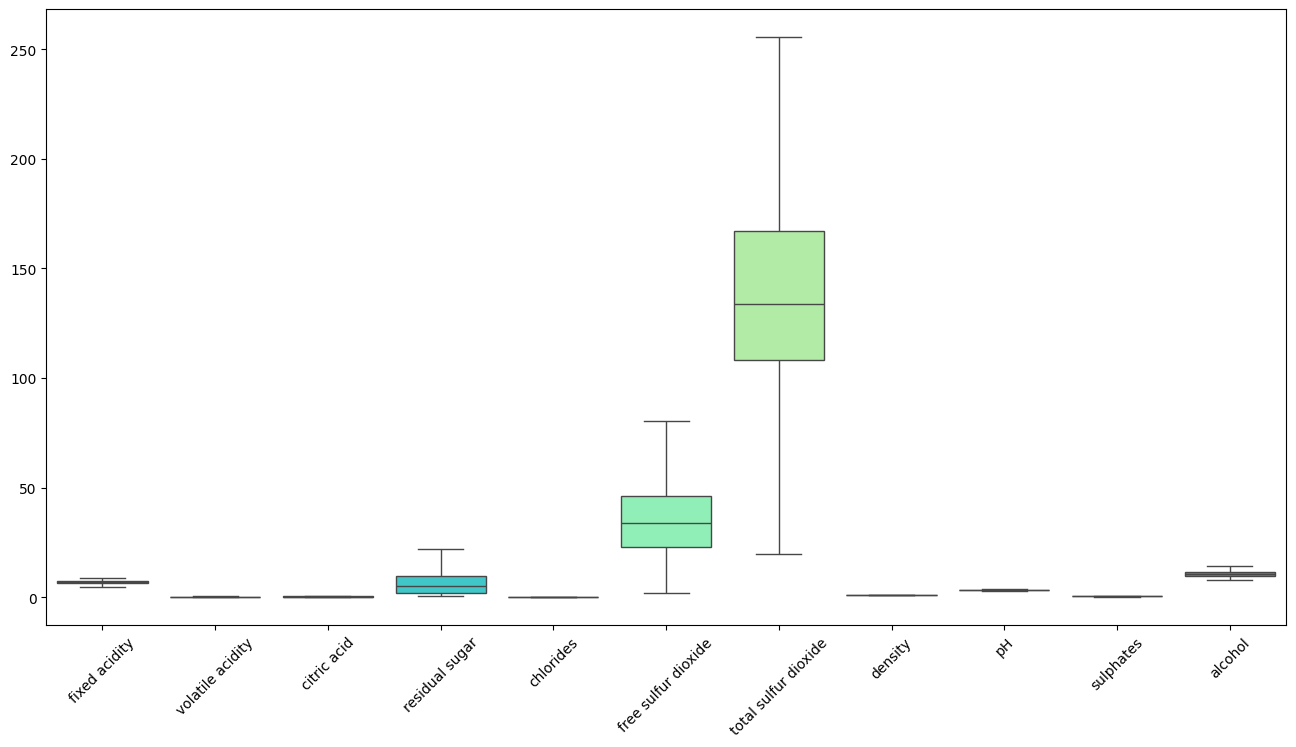

In [ ]:
plt.figure(figsize=(16,8))

sns.boxplot(data=data, palette='rainbow')

plt.xticks(rotation=45)
plt.show()

**-- Separar las variables**

In [ ]:
features = data.iloc[:, 0:11]
target = data.iloc[:, -1]
features.head(5)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9


In [ ]:
target.head(5)

,quality_label
0,medium
1,medium
2,medium
3,medium
4,medium


**--- División del conjunto de entranamiento y prueba**

In [ ]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_Y, test_Y = train_test_split(features, target, test_size=0.3, random_state=42, shuffle=True)

**--- Balanceo de los datos**

In [ ]:
# balanceo solo con los datos de entrenamiento

from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import LabelEncoder

over_sampler = SMOTE(k_neighbors=5)
train_XB, train_YB = over_sampler.fit_resample(train_X, train_Y)
print(f"Training target statistics: {Counter(train_YB)}")

encoder_ = LabelEncoder()
train_YB = encoder_.fit_transform(train_YB)


Training target statistics: Counter({'medium': 2130, 'low': 2130, 'high': 2130})


In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb

model_xgb = xgb.XGBClassifier(
            objective='multi:softprob',  # or 'multi:softmax'
            num_class=3,
            n_estimators=500,
            max_depth=32,
            learning_rate=0.1,
            subsample=0.8,
            eval_metric='logloss'
)

In [ ]:
# entrenamiento del modelo

model_xgb.fit(train_XB, train_YB, verbose=2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=32, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=3, ...)

In [ ]:
# evaluacion del modelo

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sb

test_X = copy.deepcopy(test_X)
test_Y = encoder_.fit_transform(test_Y)
predict_Y = model_xgb.predict(test_X)
print(confusion_matrix(test_Y, predict_Y))
print(classification_report(test_Y, predict_Y))

[[ 21   1  27]
 [  1 357 115]
 [ 29 141 778]]
              precision    recall  f1-score   support

           0       0.41      0.43      0.42        49
           1       0.72      0.75      0.73       473
           2       0.85      0.82      0.83       948

    accuracy                           0.79      1470
   macro avg       0.66      0.67      0.66      1470
weighted avg       0.79      0.79      0.79      1470



**Conclusión a partir de los resultados**

Se han realizado algunas pruebas incluyendo 100, 200 y 500 predictores. Con 500 predictores y un max_deep de 32 se obtuvieron los mejores resultados. Sin embargo, la clase 0 que es "medium" y la clase 1 que es "low" presentan un F1-score menor a 0.8. La que mayor problema presenta en la clasificación es la clase "medium".

Text(50.722222222222214, 0.5, 'Real values')

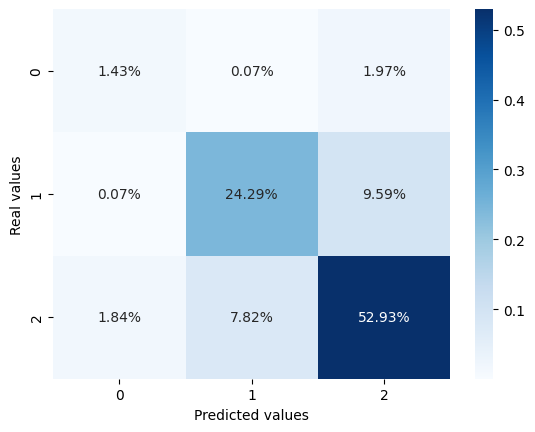

In [ ]:
matrix = confusion_matrix(predict_Y, test_Y)
ax = sb.heatmap(matrix/np.sum(matrix), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

**Conclusión a partir de la matriz de confusión**

Se puede notar que la clase 0 correspondiente a "medium" presenta errores tipo 1 y 2, es decir no logra clasificar el modelo de forma correcta los valores reales que corresponden a la clase y predice otros valores que no corresponden. Esto puede deberse a la naturaleza de los datos.


In [ ]:
import lightgbm as lgb

In [ ]:
# Definición de parámetros para LightGBM
params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'verbose': 2
}

# Creación del dataset
train_data = lgb.Dataset(train_XB, label=train_YB)
valid_data = lgb.Dataset(test_X, label=test_Y, reference=train_data)

In [ ]:
# Entrenamiento del modelo

model_lgb = lgb.train(params=params,
                      train_set=train_data,
                      num_boost_round=300,
                      valid_sets=[train_data, valid_data],
                      callbacks=[
                        lgb.early_stopping(stopping_rounds=10),
                        lgb.log_evaluation(period=10)]
                      )

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.000000
[LightGBM] [Debug] init for col-wise cost 0.000008 seconds, init for row-wise cost 0.008991 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024874 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2803
[LightGBM] [Info] Number of data points in the train set: 6390, number of used features: 11
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Debug] Trained a tree with leaves = 64 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 64 and depth = 10
[LightGBM] [Debug] Trained a tree with leaves = 64 and depth = 26
Training until 

In [ ]:
# EVALUACIÓN DEL MODELO

predict_Y_lgb = model_lgb.predict(test_X)
predict_Y_lgb = np.argmax(predict_Y_lgb, axis=1)
print(classification_report(test_Y, predict_Y_lgb))

[[ 21   1  27]
 [  1 357 115]
 [ 29 141 778]]
              precision    recall  f1-score   support

           0       0.35      0.51      0.42        49
           1       0.67      0.73      0.70       473
           2       0.83      0.77      0.80       948

    accuracy                           0.75      1470
   macro avg       0.62      0.67      0.64      1470
weighted avg       0.76      0.75      0.75      1470



**Conclusión a partir de los resultados**

De forma similar al algoritmo anterior, se han realizado algunas pruebas incluyendo 100, 200 y 300 predictores. Con 300 predictores y un num_leaves de 64 se obtuvieron los mejores resultados. Sin embargo, la clase 0  que es "medium" y la clase 1 que es "low" siguen presentando un F1-score menor a 0.8. La que mayor problema presenta en la clasificación es la clase "medium".

Text(50.722222222222214, 0.5, 'Real values')

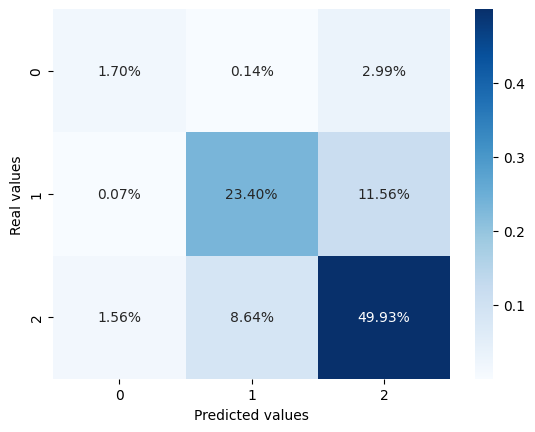

In [ ]:
matrix_lgb = confusion_matrix(predict_Y_lgb, test_Y)
ax = sb.heatmap(matrix_lgb/np.sum(matrix_lgb), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

**Conclusión a partir de la matriz de confusión**

Se puede notar que la clase 0 correspondiente a "medium" presenta errores tipo 1 y 2, es decir no logra clasificar el modelo de forma correcta los valores reales que corresponden a la clase y predice otros valores que no corresponden. Comparando con el algoritmo anterior, los resultados han disminuido en un 2% la precisión alcanzada. Esto puede deberse a la naturaleza de los datos.

In [ ]:
# Prueba con normalización de los datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [ ]:
# división conjunto de datos 80 - 20

train_Xs, test_Xs, train_Ys, test_Ys = train_test_split(features_scaled, target, test_size=0.2, random_state=42, shuffle=True)

In [ ]:
# balanceo de datos

over_sampler_s = SMOTE(k_neighbors=10)
train_XBs, train_YBs = over_sampler.fit_resample(train_Xs, train_Ys)
print(f"Training target statistics: {Counter(train_YBs)}")

encoder_ = LabelEncoder()
train_YBs = encoder_.fit_transform(train_YBs)
test_Ys = encoder_.fit_transform(test_Ys)


Training target statistics: Counter({'medium': 2454, 'low': 2454, 'high': 2454})


In [ ]:
# Definición de parámetros para LightGBM
params2 = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,
    'num_leaves': 64,
    'verbose': 2
}

# Creación del dataset
train_data_s = lgb.Dataset(train_XBs, label=train_YBs)
valid_data_s = lgb.Dataset(test_Xs, label=test_Ys, reference=train_data_s)

In [ ]:
# Entrenamiento del modelo

model_lgb_2 = lgb.train(params=params2,
                      train_set=train_data_s,
                      num_boost_round=300,
                      valid_sets=[train_data_s, valid_data_s],
                      callbacks=[
                        lgb.early_stopping(stopping_rounds=10),
                        lgb.log_evaluation(period=10)]
                      )

[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.000000
[LightGBM] [Debug] init for col-wise cost 0.000006 seconds, init for row-wise cost 0.000772 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001047 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 7362, number of used features: 11
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Debug] Trained a tree with leaves = 64 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 64 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 64 and depth = 12
Training until validation scores don't improve for 10 rounds
[LightGBM] [Debug] Trained a tree with leaves = 64 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 6

In [ ]:
# EVALUACIÓN DEL MODELO 2
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sb

predict_Y_lgb_s = model_lgb_2.predict(test_Xs)
predict_Y_lgb_s = np.argmax(predict_Y_lgb_s, axis=1)
print(classification_report(test_Ys, predict_Y_lgb_s))

              precision    recall  f1-score   support

           0       0.39      0.57      0.47        35
           1       0.67      0.70      0.69       321
           2       0.81      0.78      0.79       624

    accuracy                           0.74       980
   macro avg       0.63      0.68      0.65       980
weighted avg       0.75      0.74      0.75       980



**Conclusión a partir de los resultados**

De forma similar al algoritmo anterior, se han realizado algunas pruebas incluyendo 100, 200 y 300 predictores. Con 300 predictores y un num_leaves de 64 se obtuvieron los mejores resultados. Existe un leve mejora en la clasificación de la clase 0. Sin embargo, la clase 0  que es "medium" y la clase 1 que es "low" siguen presentando un F1-score menor a 0.8. La que mayor problema presenta en la clasificación es la clase "medium".

Text(50.722222222222214, 0.5, 'Real values')

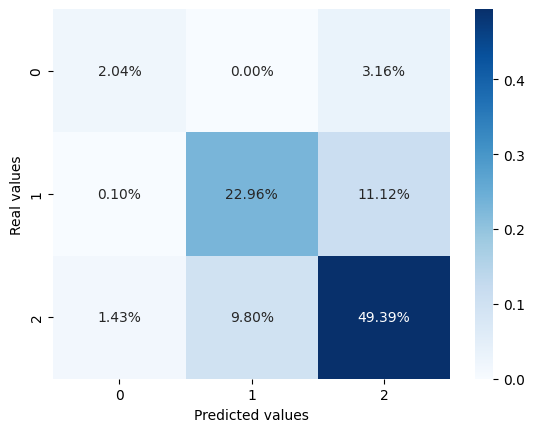

In [ ]:
matrix_lgb_s = confusion_matrix(predict_Y_lgb_s, test_Ys)
ax = sb.heatmap(matrix_lgb_s/np.sum(matrix_lgb_s), annot=True, fmt='.2%', cmap='Blues')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Real values')

**Conclusión a partir de la matriz de confusión**

Se puede notar que la clase 0 correspondiente a "medium" presenta errores tipo 1 y 2, es decir no logra clasificar el modelo de forma correcta los valores reales que corresponden a la clase y predice otros valores que no corresponden. Comparando con el algoritmo anterior, los resultados han mejorado en un 1.5% la precisión alcanzada. Lo que indica que la normalización de los datos, hace que el algoritmo pueda discriminar de mejor manera las clases.